# Métodos de Regularización

Sebastián Aguilar Benavides


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge


In [8]:
# Construcción de variables 

x1 = np.arange(-1, 3.5, 0.125) # La variacion entre un dato y el otro es de 0.125

In [9]:
x2 = x1 * x1
x3 = x1 * x1 * x1

In [10]:
# Dataset


w = np.concatenate((np.vstack(x1), np.vstack(x2), np.vstack(x3)), axis=1)

X = pd.DataFrame(w, columns=['x1', 'x2', 'x3'])

In [11]:
X.head()

,x1,x2,x3
0,-1.000,1.000000,-1.000000
1,-0.875,0.765625,-0.669922
2,-0.750,0.562500,-0.421875
3,-0.625,0.390625,-0.244141
4,-0.500,0.250000,-0.125000


In [12]:
# Coeficientes de la ecuación polinómica (pesos)
w0 = 190
w1 = -85/3
w2 = -165
w3 = 160/3 

In [13]:
noise = 200 * (random.random() - 0.5) # Ruido aleatorio

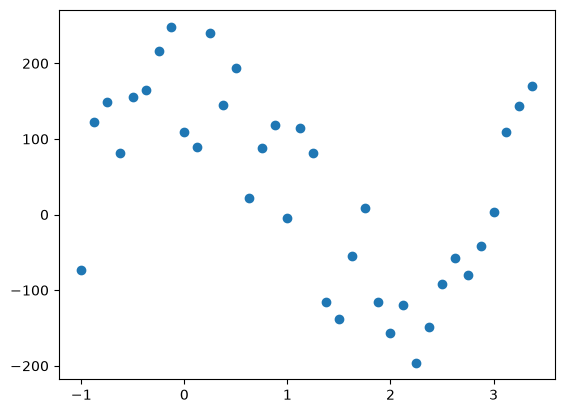

In [14]:
# Definimos nuestra variable de salida con algo de ruido para que nuestro problema
# no se reduzca simplemente a un problema de interpolación de puntos:

random.seed(1)
yreal = []
for x in x1:
  noise=200*(random.random() -0.5)
  cc = w3*np.power(x,3) + w2*np.power(x,2) + w1*x + w0 + noise
  yreal.append(cc)
  
  
plt.scatter(x1,yreal)
plt.show()


In [15]:
# Modelos entrenados
modelos = []
modelos.append(('LR', LinearRegression()))
modelos.append(('LASSO', Lasso(alpha=30)))
modelos.append(('RIDGE', Ridge(alpha=30)))
modelos.append(('EN', ElasticNet(alpha=1, l1_ratio=.5)))

In [16]:
yhat0 = [] # RLM
yhat1 = [] # LASSO
yhat2 = [] # RIDGE
yhat12 = [] # ElasticNet

In [17]:
for name, model in modelos:
  # entrenamos el modelo seleccionado y obtenemos sus predicciones:
  print("%s:" % name)
  mm = model.fit(X, np.ravel(yreal))
  yhat = mm.predict(X)
  
  print(mm.intercept_)   # por si deseas conocer w0.
  print(mm.coef_)       # despleguemos los pesos obtenidos

  if name=='LR':
    yhat0.append(yhat)
    print('\n')
  elif name=='LASSO':
    yhat1.append(yhat)
    print('\n')
  elif name=='RIDGE':
    yhat2.append(yhat)
    print('\n')
  else:
    yhat12.append(yhat)

LR:
188.7650456272432
[ -29.33337114 -168.24288551   52.77023437]


LASSO:
106.26730286980037
[ -9.75044141 -63.60028022  18.30265562]


RIDGE:
99.96767698770284
[-31.82780343 -44.18760024  14.71070949]


EN:
114.2133098649908
[-38.83633535 -59.92058497  20.28138036]


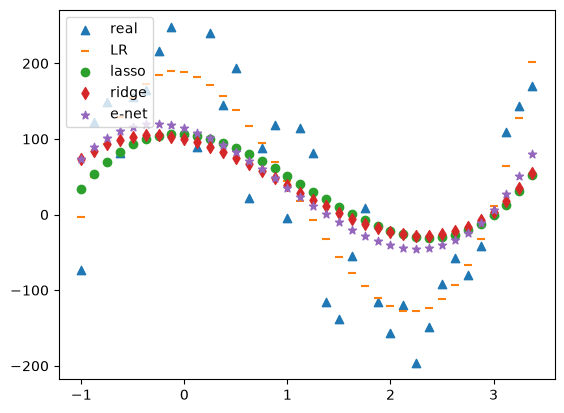

In [18]:
# Visualizacón de los resultados
plt.scatter(x1, np.ravel(yreal), marker='^', label='real')  

plt.scatter(x1, np.ravel(yhat0), marker='_', label='LR')  
plt.scatter(x1, np.ravel(yhat1), marker='o', label='lasso')  
plt.scatter(x1, np.ravel(yhat2), marker='d', label='ridge')  
plt.scatter(x1, np.ravel(yhat12), marker='*', label='e-net')

plt.legend(loc=2)
plt.show()